# Clasificador base
Después de hacer el EDA, se definió que el feature Redshift es la variable con mayor poder predictivo para las clases. Con esta variable entonces, se decide diseñar un modelo baseline muy sencillo que podamos usar para verificar como nuestros algoritmos de ML mejoran (o no) la clasificación.
Este modelo baseline simplemente estará compuesto por dos cortes para valores del redshift, definiendo 3 secciones las cuales representarán a las clases del target.
A ojo, se pudo identificar que los cortes están cerca de $0.0045$ y $1.0$, pero se procede a aplicar técnicas un poco más elegantes:

In [36]:
import pandas as pd

df = pd.read_csv('../dataset/star_classification.csv')
# Cantidad de registros anómalos
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

## Decision tree de 3 hojas
Se calcula un modelo de decision tree que solo pueda clasificar mediante el redshift y que solo tenga 3 hojas (una por clase). Este naturalmente nos llevaría a definir los cortes matemáticamente óptimos para separar las clases

Los 2 cortes matemáticamente óptimos encontrados son: [np.float64(0.004171235021203756), np.float64(1.001039981842041)]


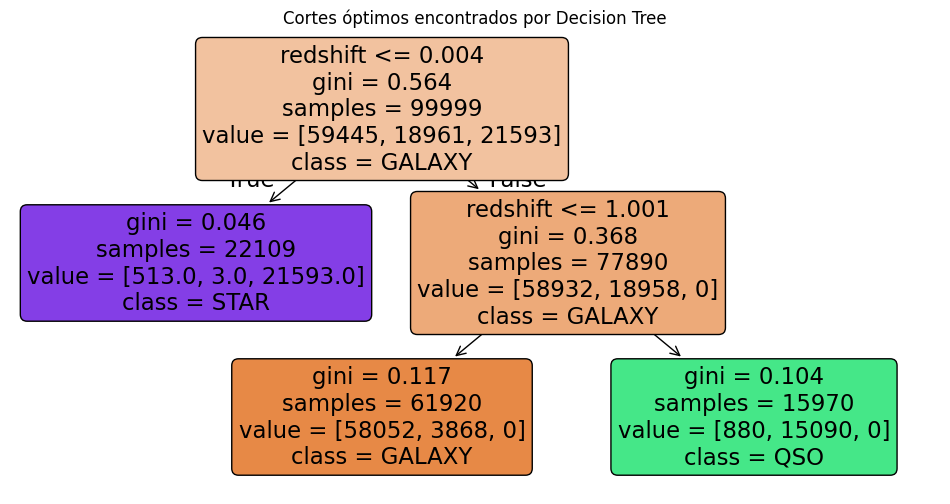

In [37]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Preparamos los datos (el modelo pide datos 2D para X)
X = df[['redshift']]
y = df['class']
# 2. Entrenamos un árbol limitando a 3 nodos finales (exactamente 2 cortes)
dt_baseline = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
dt_baseline.fit(X, y)
# 3. Extraemos los valores de corte de la estructura interna del árbol (ignoramos los nodos hoja marcados como -2)
cortes_optimos = dt_baseline.tree_.threshold[dt_baseline.tree_.threshold != -2]
print(f"Los 2 cortes matemáticamente óptimos encontrados son: {sorted(cortes_optimos)}")

plt.figure(figsize=(12, 6))
plot_tree(dt_baseline, feature_names=['redshift'], class_names=dt_baseline.classes_, filled=True, rounded=True)
plt.title('Cortes óptimos encontrados por Decision Tree')
plt.show()

Los cortes encontrados son 0.004171235021203756 y 1.001039981842041, aunque usar este baseline podría considerarse una trampa porque, aunque sencillo, ya se está implementando un modelo de Machine Learning.

Igualmente evaluemos el desempeño en clasificación con todo el modelo:

In [38]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

In [39]:
c1 = sorted(cortes_optimos)[0]
c2 = sorted(cortes_optimos)[1]

cortes = [-np.inf, c1, c2, np.inf]
etiquetas = ['STAR', 'GALAXY', 'QSO']

df['baseline_pred'] = pd.cut(df['redshift'], bins=cortes, labels=etiquetas)

print("Reporte de clasificación del baseline con dataframe completo")
print(classification_report(df['class'], df['baseline_pred']))
print(f"Precisión: {accuracy_score(df['class'], df['baseline_pred']):.4f}")

Reporte de clasificación del baseline con dataframe completo
              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96     59445
         QSO       0.94      0.80      0.86     18961
        STAR       0.98      1.00      0.99     21593

    accuracy                           0.95     99999
   macro avg       0.95      0.92      0.94     99999
weighted avg       0.95      0.95      0.95     99999

Precisión: 0.9474


## Búsqueda mediante GridSearch
Conociendo el valor aproximado de los cortes a partir de la identificación visual, definimos una búsqueda de grilla alrededor de estos para encontrar mejores valores.

In [40]:
cortes_1 = np.linspace(0.004, 0.005, 50)
cortes_2 = np.linspace(0.998, 1.002, 50)

best_accuracy = 0
best_cortes = None

for c1 in cortes_1:
    for c2 in cortes_2:
        bins = [-np.inf, c1, c2, np.inf]
        labels = ['STAR', 'GALAXY', 'QSO']
        
        preds = pd.cut(df['redshift'], bins=bins, labels=labels)

        accuracy = accuracy_score(df['class'], preds)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_cortes = (c1, c2)

print("Mejores cortes: ", best_cortes)
print(f"Precisión: {best_accuracy:.4f}")

Mejores cortes:  (np.float64(0.004163265306122449), np.float64(1.0009387755102042))
Precisión: 0.9474


Considero que la búsqueda de cortes mediante este método es más válida para un baseline que la anterior, y la precisión obtenida es prácticamente la misma. La diferencia en el valor de los cortes también es mínima: 0.004163265306122449 y 1.0009387755102042

## Búsqueda Bayesiana (Optuna)
Se utiliza el framework Optuna para aplicar una búsqueda inteligente de los mejores cortes.

In [41]:
import optuna

def objective(trial):
    # Le pedimos a Optuna que sugiera un par flotante en estos rangos
    c1 = trial.suggest_float('corte_1', -0.01, 0.05)
    c2 = trial.suggest_float('corte_2', 0.5, 3.0)
    
    # Obligamos a descartar la rama de búsqueda si propuso un orden imposible
    if c1 >= c2:
        raise optuna.TrialPruned()
        
    bins = [-np.inf, c1, c2, np.inf]
    labels = ['STAR', 'GALAXY', 'QSO']
    
    # Predecimos usando los cortes de esta iteración
    preds = pd.cut(df['redshift'], bins=bins, labels=labels)
    
    # Como el estudio está en modo "maximize", buscamos devolver la métrica más alta
    return accuracy_score(df['class'], preds)

# Escondemos un poco de log verborrágico de Optuna y corremos la optimización
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300)

print(f"Mejores cortes: {study.best_params}")
print(f"Máxima precisión: {study.best_value:.4f}")


Mejores cortes: {'corte_1': 0.004791120236059248, 'corte_2': 1.0066463898016755}
Máxima precisión: 0.9472


La precisión es muy similar a las anteriores, apenas inferior, sin embargo es interesante ver que los cortes se alejan relativamente bastante respecto de los obtenidos previamente.

Se compone un cuadro comparativo para relevar todos los resultados en un solo lugar. Estos corresponden a una ejecución, pero pueden cambiar levemente al volver a ejecutar el notebook:

| Método | Precisión | Corte 1 | Corte 2 |
| ------ | --------- | ------- | ------- |
| Manual | 0.9472 | 0.0045 | 1.0 |
| Decision Tree | 0.9474 | 0.004171235021203756 | 1.001039981842041 |
| GridSearch | 0.9474 | 0.004163265306122449 | 1.0009387755102042 |
| Optuna | 0.9473 | 0.004288895205053125 | 0.9924400879421378 |

A fines prácticos, lo único que nos interesa es definir una precisión base con la cual comparar el desempeño de los modelos de Machine Learning que vayamos implementando. Esta es **0.9474**.

## Dataframe reducido
Vamos a volver a realizar las mismas mediciones y clasificaciones pero ahora para el dataframe reducido, es decir, aquel en el cual se eliminaron todos los registros que corresponden a una clase minoritaria en los grupos de mediciones para un mismo obj_ID.

In [42]:
group_counts = df.groupby('obj_ID').size()
duplicated_obj_ids = group_counts[group_counts > 1].index
unique_obj_ids = group_counts[group_counts == 1].index

# 2. Analizar la situación de cada grupo con múltiples registros
rows_to_keep = []
total_discarded = 0

for obj_id in duplicated_obj_ids:
    group = df[df['obj_ID'] == obj_id]
    class_counts = group['class'].value_counts()
    
    # Verificar si hay más de una clase en el grupo
    has_conflict = len(class_counts) > 1
    majority_class = class_counts.idxmax()
    majority_count = class_counts.max()
    total_in_group = len(group)
    
    if has_conflict:
        minority_count = total_in_group - majority_count
        total_discarded += minority_count
    
    # Conservar solo los registros de la clase mayoritaria
    rows_to_keep.append(group[group['class'] == majority_class])

# 3. Agregar los registros de obj_IDs únicos (sin duplicados)
unique_rows = df[df['obj_ID'].isin(unique_obj_ids)]

# 4. Construir el DataFrame filtrado
df_majority = pd.concat([unique_rows] + rows_to_keep, ignore_index=True)

print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)
print(f"Registros originales: {len(df)}")
print(f"Registros descartados por clase minoritaria: {total_discarded}")
print(f"Registros en df_majority: {len(df_majority)}")
print(f"\nDistribución de clases en df original:")
print(df['class'].value_counts())
print(f"\nDistribución de clases en df_majority:")
print(df_majority['class'].value_counts())

df = df_majority


RESUMEN FINAL
Registros originales: 99999
Registros descartados por clase minoritaria: 6340
Registros en df_majority: 93659

Distribución de clases en df original:
class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64

Distribución de clases en df_majority:
class
GALAXY    57928
STAR      19345
QSO       16386
Name: count, dtype: int64


### Manual
Como evidentemente la predicción manual no es la mejor, no se va a volver a repetir para este caso, ya que involucraría repetir algunas partes del EDA para el nuevo dataset y es demasiado trabajo para algo que se sabe que no va a ser de verdadera utilidad. Al no realizar esta parte, el espacio que se explora en el GridSearch podría no ser el mejor, pero puede saberse a posteriori luego de comparar con las demás búsquedas.

### Decision Tree

In [43]:
# 1. Preparamos los datos (el modelo pide datos 2D para X)
X = df[['redshift']]
y = df['class']
# 2. Entrenamos un árbol limitando a 3 nodos finales (exactamente 2 cortes)
dt_baseline = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
dt_baseline.fit(X, y)
# 3. Extraemos los valores de corte de la estructura interna del árbol (ignoramos los nodos hoja marcados como -2)
cortes_optimos = dt_baseline.tree_.threshold[dt_baseline.tree_.threshold != -2]
print(f"Los 2 cortes matemáticamente óptimos encontrados son: {sorted(cortes_optimos)}")

c1 = sorted(cortes_optimos)[0]
c2 = sorted(cortes_optimos)[1]

cortes = [-np.inf, c1, c2, np.inf]
etiquetas = ['STAR', 'GALAXY', 'QSO']

df['baseline_pred'] = pd.cut(df['redshift'], bins=cortes, labels=etiquetas)

print("Reporte de clasificación del baseline con dataframe completo")
print(classification_report(df['class'], df['baseline_pred']))
print(f"Precisión: {accuracy_score(df['class'], df['baseline_pred']):.4f}")

Los 2 cortes matemáticamente óptimos encontrados son: [np.float64(0.004171235021203756), np.float64(1.0058819651603699)]
Reporte de clasificación del baseline con dataframe completo
              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96     57928
         QSO       0.94      0.80      0.86     16386
        STAR       0.98      1.00      0.99     19345

    accuracy                           0.95     93659
   macro avg       0.95      0.92      0.94     93659
weighted avg       0.95      0.95      0.95     93659

Precisión: 0.9507


### GridSearch

In [44]:
cortes_1 = np.linspace(0.004, 0.005, 50)
cortes_2 = np.linspace(0.998, 1.002, 50)

best_accuracy = 0
best_cortes = None

for c1 in cortes_1:
    for c2 in cortes_2:
        bins = [-np.inf, c1, c2, np.inf]
        labels = ['STAR', 'GALAXY', 'QSO']
        
        preds = pd.cut(df['redshift'], bins=bins, labels=labels)

        accuracy = accuracy_score(df['class'], preds)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_cortes = (c1, c2)

print("Mejores cortes: ", best_cortes)
print(f"Precisión: {best_accuracy:.4f}")

Mejores cortes:  (np.float64(0.004163265306122449), np.float64(1.0009387755102042))
Precisión: 0.9507


### Búsqueda Bayesiana (Optuna)

In [45]:
import optuna

def objective(trial):
    # Le pedimos a Optuna que sugiera un par flotante en estos rangos
    c1 = trial.suggest_float('corte_1', -0.01, 0.05)
    c2 = trial.suggest_float('corte_2', 0.5, 3.0)
    
    # Obligamos a descartar la rama de búsqueda si propuso un orden imposible
    if c1 >= c2:
        raise optuna.TrialPruned()
        
    bins = [-np.inf, c1, c2, np.inf]
    labels = ['STAR', 'GALAXY', 'QSO']
    
    # Predecimos usando los cortes de esta iteración
    preds = pd.cut(df['redshift'], bins=bins, labels=labels)
    
    # Como el estudio está en modo "maximize", buscamos devolver la métrica más alta
    return accuracy_score(df['class'], preds)

# Escondemos un poco de log verborrágico de Optuna y corremos la optimización
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300)

print(f"Mejores cortes: {study.best_params}")
print(f"Máxima precisión: {study.best_value:.4f}")


Mejores cortes: {'corte_1': 0.004181117672439855, 'corte_2': 0.9945457303812224}
Máxima precisión: 0.9507


Generamos un nuevo cuadro comparativo para el dataframe reducido, eliminando la fila de búsqueda manual, ya que no se hizo para este.

| Método | Precisión | Corte 1 | Corte 2 |
| ------ | --------- | ------- | ------- |
| Decision Tree | 0.9507 | 0.004171235021203756 | 1.0058819651603699 |
| GridSearch | 0.9507 | 0.004163265306122449 | 1.0009387755102042 |
| Optuna | 0.9507 | 0.004181117672439855 | 0.9945457303812224 |